# 26_distribution_shift_diagnostic.ipynb

Минимальный эксперимент, который различает **memorization** vs
**distribution shift** как причину train→test gap.

## Что мы знаем сейчас

| Модель | Train RMSE | Val RMSE | Test RMSE | T→T ratio |
|---|---|---|---|---|
| vanilla FNO | 4.43 | 9.98 | 16.74 | 3.8× |
| vanilla U-Net | 7.18 | 10.29 | 18.46 | 2.6× |
| GeoUNet v1 | ? | 9.73 | 18.77 | — |
| GeoUNet v2 | 5.42 | 8.85 | 18.15 | 3.3× |

Все модели показывают одинаковый паттерн: train ≪ val ≪ test, ratio 3-4×.
Никакая capacity, регуляризация или архитектурная замена scatter↔bilinear
эту дыру не закрывает. Это намекает, что причина не в архитектуре, а в
**данных** или **протоколе оценки**.

## Какая разница между memorization и distribution shift

- **Memorization (Hypothesis A):** train RMSE 4.4 м/с возникает потому, что
  модель «выучила» конкретные 6200 примеров. На любом **новом** примере (хоть
  из train-распределения, хоть из test) она дала бы похожий результат —
  сильно хуже, чем 4.4. Train→test gap — это просто demo «memorization».

- **Distribution shift (Hypothesis B):** train, val, test — реально разные
  по структуре. Модель действительно научилась решать задачу на train-
  распределении (там RMSE 4-5 даже на новых примерах из этого же
  распределения), но test пришёл из другого распределения, где модель
  работает хуже. Тогда увеличение данных в train не поможет, нужно либо
  собирать данные в распределении test, либо менять generalization-стратегию.

Эти два сценария требуют **совершенно разных** действий, и до сих пор мы
гадали, какой из них верен.

## Эксперимент

1. Из 6200 train-файлов отделяем **последние 1000** в "train-fresh". Они
   будут той же распределённости, что и train, но **не увидены при обучении**.
2. Обучаем vanilla FNO **только на 5200** оставшихся train-файлов.
   Гиперпараметры идентичны `16_fno_train.ipynb`.
3. После обучения оцениваем модель на четырёх множествах:
   - **train-seen** (5200): что модель видела
   - **train-fresh** (1000): главная метрика — same distribution, never seen
   - **val** (1000): прежний val
   - **test** (800): прежний test

## Что покажут результаты

| train-seen | train-fresh | test | вердикт |
|---|---|---|---|
| ~4 | ~4-5 | ~17 | distribution shift (Hypothesis B): train и test разные |
| ~4 | ~14-17 | ~17 | memorization (Hypothesis A): модель запомнила, gap = memorization |
| ~6 | ~6-7 | ~17 | смешанный режим — частично shift, частично under-trained |

В первом сценарии любые архитектурные эксперименты будут бесполезны без
фикса распределения. Во втором — всё ещё имеет смысл искать архитектуры,
которые меньше переобучаются.

## Стоимость

Один 30-минутный run обучения. Никакой перегенерации датасета — только
переразбивка существующих файлов.

## 1. Импорты и конфиг

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
from pathlib import Path
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "device:", device)

torch: 2.11.0+cu130 device: cuda


In [3]:
CFG = {
    "dataset_root": "/workspace/usct_dataset_v2",
    "run_name": "distribution_shift_diagnostic",
    "batch_size": 8,
    # Match 16_fno_train.ipynb hyperparameters exactly so results compare directly
    "epochs": 180,
    "patience": 30,
    "lr": 1e-3,
    "min_lr": 1e-5,
    "weight_decay": 1e-6,
    "num_workers": 0,
    "mask_half_width": 2,
    "use_residual": True,

    # FNO body — identical to 16_fno_train.ipynb
    "fno_width": 48,
    "fno_depth": 4,
    "fno_modes_h": 24,
    "fno_modes_w": 24,
    "fno_padding": 8,

    # LR schedule
    "scheduler_factor": 0.5,
    "scheduler_patience": 8,

    # The new split: how many train files become train-fresh
    "heldout_size": 1000,
}
CFG

{'dataset_root': '/workspace/usct_dataset_v2',
 'run_name': 'distribution_shift_diagnostic',
 'batch_size': 8,
 'epochs': 180,
 'patience': 30,
 'lr': 0.001,
 'min_lr': 1e-05,
 'weight_decay': 1e-06,
 'num_workers': 0,
 'mask_half_width': 2,
 'use_residual': True,
 'fno_width': 48,
 'fno_depth': 4,
 'fno_modes_h': 24,
 'fno_modes_w': 24,
 'fno_padding': 8,
 'scheduler_factor': 0.5,
 'scheduler_patience': 8,
 'heldout_size': 1000}

## 2. Файлы и переразбивка

Берём первые `len(train_files) - heldout_size` примеров для обучения, оставшиеся
1000 — `train-fresh`. Для воспроизводимости фиксируем seed на shuffle до разбивки.

In [4]:
OUT_ROOT = Path(CFG["dataset_root"])
TRAIN_DIR = OUT_ROOT / "train"
VAL_DIR = OUT_ROOT / "val"
TEST_DIR = OUT_ROOT / "test"

orig_train_files = sorted(TRAIN_DIR.glob("*.npz"))
val_files = sorted(VAL_DIR.glob("*.npz"))
test_files = sorted(TEST_DIR.glob("*.npz"))

# Deterministic shuffle of original train, then split.
rng = np.random.RandomState(SEED)
shuffled_idx = rng.permutation(len(orig_train_files))
n_held = CFG["heldout_size"]
n_train = len(orig_train_files) - n_held

train_seen_idx = sorted(shuffled_idx[:n_train].tolist())
train_fresh_idx = sorted(shuffled_idx[n_train:].tolist())

train_seen_files  = [orig_train_files[i] for i in train_seen_idx]
train_fresh_files = [orig_train_files[i] for i in train_fresh_idx]

print(f"orig train:  {len(orig_train_files)}")
print(f"  ├─ train-seen  (used for training):     {len(train_seen_files)}")
print(f"  └─ train-fresh (held-out from training): {len(train_fresh_files)}")
print(f"val:    {len(val_files)}")
print(f"test:   {len(test_files)}")

# Save the split for reproducibility
split_path = Path("/workspace/reference_points") / CFG["run_name"] / "split_manifest.json"
split_path.parent.mkdir(parents=True, exist_ok=True)
with open(split_path, "w", encoding="utf-8") as f:
    json.dump({
        "seed": SEED,
        "train_seen": [str(p) for p in train_seen_files],
        "train_fresh": [str(p) for p in train_fresh_files],
        "val": [str(p) for p in val_files],
        "test": [str(p) for p in test_files],
    }, f, ensure_ascii=False, indent=2)
print(f"\nsaved split manifest to {split_path}")

orig train:  6200
  ├─ train-seen  (used for training):     5200
  └─ train-fresh (held-out from training): 1000
val:    1000
test:   800

saved split manifest to /workspace/reference_points/distribution_shift_diagnostic/split_manifest.json


### 2.1 Статистика по target из train-seen

Важно: `c_min`/`c_max` считаем **только** на train-seen (на которой обучается
модель), как и было бы в продакшене.

In [5]:
sample0 = np.load(train_seen_files[0])

S, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y_full = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x_full = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

# c-stats from train-seen only
all_c_values = []
for p in train_seen_files:
    all_c_values.append(np.load(p)["c"].astype(np.float32))
all_c_values = np.stack(all_c_values, axis=0)
stats = {"c_min": float(all_c_values.min()), "c_max": float(all_c_values.max())}
del all_c_values

print("S, R, H, W:", S, R, H, W)
print("freq_hz:", freq_hz)
print("stats (from train-seen):", stats)

S, R, H, W: 16 256 192 192
freq_hz: 500000.0
stats (from train-seen): {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125}


## 3. `M_hom` через j-Wave

Идентичный блок из `16_fno_train.ipynb`.

In [6]:
import jax
import jax.numpy as jnp
from jax import jit
from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

def gaussian_source(H, W, y0, x0, sigma=1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

full_source_fields = []
for ridx in source_ring_idx_full:
    y0, x0 = int(receiver_y_full[ridx]), int(receiver_x_full[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=1.8)
    full_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
full_source_fields = tuple(full_source_fields)

def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    return Medium(domain=domain, sound_speed=sound_speed, density=1000.0, pml_size=16)

def forward_measurements_full(c_map):
    medium = make_medium(c_map)
    ms = []
    for i in range(len(full_source_fields)):
        src = FourierSeries(jnp.expand_dims(full_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y_full, receiver_x_full])
    return jnp.stack(ms, axis=0)

forward_measurements_full_jit = jit(forward_measurements_full)

c_hom = jnp.full((H, W), 1500.0, dtype=jnp.float32)
M_hom_complex = forward_measurements_full_jit(c_hom)
M_hom_complex.block_until_ready()
M_hom_complex = np.array(M_hom_complex)
print("M_hom_complex:", M_hom_complex.shape, M_hom_complex.dtype)

/tmp/ipykernel_1962/2981668139.py:8: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


M_hom_complex: (16, 256) complex64


## 4. Dataset

Тот же `USCTFNODataset` из `16_fno_train.ipynb`. Возвращает `(x, c)` в том же
виде, что vanilla FNO ожидает на входе.

In [7]:
def mask_self_receivers(M, source_ring_idx, half_width=2):
    M = M.copy()
    Sl, Rl = M.shape
    for s in range(Sl):
        ridx = int(source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % Rl
            M[s, rr] = 0.0 + 0.0j
    return M


class USCTFNODataset(Dataset):
    def __init__(self, paths, c_min, c_max, M_hom_complex,
                 use_residual=True, mask_half_width=2):
        self.paths = list(paths)
        self.c_min = float(c_min)
        self.c_max = float(c_max)
        self.c_range = max(self.c_max - self.c_min, 1e-8)
        self.M_hom_complex = M_hom_complex
        self.use_residual = bool(use_residual)
        self.mask_half_width = int(mask_half_width)

    def __len__(self):
        return len(self.paths)

    def normalize_target(self, c):
        return 2.0 * (c - self.c_min) / self.c_range - 1.0

    def denormalize_target(self, c_norm):
        return ((c_norm + 1.0) * 0.5) * self.c_range + self.c_min

    def __getitem__(self, idx):
        d = np.load(self.paths[idx])
        x_raw = d["x"].astype(np.float32)
        c = d["c"].astype(np.float32)
        source_ring_idx = d["source_ring_idx"].astype(np.int64)

        M = x_raw[0] + 1j * x_raw[1]
        if self.use_residual:
            M = M - self.M_hom_complex
        if self.mask_half_width > 0:
            M = mask_self_receivers(M, source_ring_idx, half_width=self.mask_half_width)

        x_tensor = np.stack([M.real, M.imag], axis=0).astype(np.float32)
        x_scale = float(np.percentile(np.abs(x_tensor), 99.5))
        if x_scale < 1e-8:
            x_scale = 1.0
        x_tensor = x_tensor / x_scale

        c_norm = self.normalize_target(c).astype(np.float32)
        return (
            torch.from_numpy(x_tensor),
            torch.from_numpy(c_norm).unsqueeze(0),
            {"path": str(self.paths[idx]), "x_scale": x_scale},
        )


ds_train_seen  = USCTFNODataset(train_seen_files,  stats["c_min"], stats["c_max"], M_hom_complex)
ds_train_fresh = USCTFNODataset(train_fresh_files, stats["c_min"], stats["c_max"], M_hom_complex)
ds_val         = USCTFNODataset(val_files,         stats["c_min"], stats["c_max"], M_hom_complex)
ds_test        = USCTFNODataset(test_files,        stats["c_min"], stats["c_max"], M_hom_complex)

print("train-seen :", len(ds_train_seen))
print("train-fresh:", len(ds_train_fresh))
print("val        :", len(ds_val))
print("test       :", len(ds_test))

train-seen : 5200
train-fresh: 1000
val        : 1000
test       : 800


## 5. Архитектура — vanilla FNO

Точная копия из `16_fno_train.ipynb`. Bilinear-lift `(2, 16, 256)→(2, H, W)`,
4 spectral блока, modes=24×24, width=48. С тем же autocast(enabled=False)
fix внутри SpectralConv2d.

In [8]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, modes1, modes2):
        super().__init__()
        self.in_channels = in_ch
        self.out_channels = out_ch
        self.modes1 = modes1
        self.modes2 = modes2
        scale = 1 / (in_ch * out_ch)
        self.weights1 = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(in_ch, out_ch, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        with torch.autocast(device_type=x.device.type, enabled=False):
            x = x.float()
            x_ft = torch.fft.rfft2(x)
            out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1,
                                 dtype=torch.cfloat, device=x.device)
            out_ft[:, :, : self.modes1, : self.modes2] = self.compl_mul2d(
                x_ft[:, :, : self.modes1, : self.modes2], self.weights1,
            )
            out_ft[:, :, -self.modes1:, : self.modes2] = self.compl_mul2d(
                x_ft[:, :, -self.modes1:, : self.modes2], self.weights2,
            )
            out = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return out


class FNOBlock2d(nn.Module):
    def __init__(self, width, modes1, modes2):
        super().__init__()
        self.spectral = SpectralConv2d(width, width, modes1, modes2)
        self.pointwise = nn.Conv2d(width, width, kernel_size=1)
    def forward(self, x):
        return F.gelu(self.spectral(x) + self.pointwise(x))


class FNO2dBaseline(nn.Module):
    def __init__(self, width=48, depth=4, modes1=24, modes2=24, padding=8, target_hw=(192, 192)):
        super().__init__()
        self.width = width
        self.depth = depth
        self.padding = padding
        self.target_hw = tuple(target_hw)
        self.input_proj = nn.Conv2d(4, width, kernel_size=1)  # 2 (Re/Im) + 2 (gy, gx)
        self.blocks = nn.ModuleList([FNOBlock2d(width, modes1, modes2) for _ in range(depth)])
        self.head = nn.Sequential(
            nn.Conv2d(width, width, 1), nn.GELU(),
            nn.Conv2d(width, 1, 1),
        )

    def get_grid(self, batch_size, device):
        H_, W_ = self.target_hw
        yy = torch.linspace(-1.0, 1.0, H_, device=device)
        xx = torch.linspace(-1.0, 1.0, W_, device=device)
        gy, gx = torch.meshgrid(yy, xx, indexing="ij")
        return torch.stack([gy, gx], dim=0).unsqueeze(0).repeat(batch_size, 1, 1, 1)

    def forward(self, x):
        x = F.interpolate(x, size=self.target_hw, mode="bilinear", align_corners=False)
        grid = self.get_grid(x.shape[0], x.device)
        x = torch.cat([x, grid], dim=1)
        x = self.input_proj(x)
        if self.padding > 0:
            x = F.pad(x, [0, self.padding, 0, self.padding])
        for block in self.blocks:
            x = block(x)
        if self.padding > 0:
            x = x[..., :self.target_hw[0], :self.target_hw[1]]
        return self.head(x)

In [9]:
# Sanity
model_test = FNO2dBaseline(
    width=CFG["fno_width"], depth=CFG["fno_depth"],
    modes1=CFG["fno_modes_h"], modes2=CFG["fno_modes_w"],
    padding=CFG["fno_padding"], target_hw=(H, W),
).to(device)
print(f"FNO params: {sum(p.numel() for p in model_test.parameters()):,}")

with torch.no_grad():
    _x = torch.randn(2, 2, S, R, device=device)
    _y = model_test(_x)
    print("output:", tuple(_y.shape))
    assert _y.shape == (2, 1, H, W)

del model_test
if torch.cuda.is_available():
    torch.cuda.empty_cache()

FNO params: 10,628,881
output: (2, 1, 192, 192)


## 6. Тренировочные хелперы

Идентичны `16_fno_train.ipynb`. AMP отключён из-за complex weights.

In [10]:
def denorm_c_from_minus1_1(c_norm, c_min, c_max):
    return ((c_norm + 1.0) * 0.5) * (c_max - c_min) + c_min

def mse(a, b): return float(np.mean((a - b) ** 2))
def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def relative_l2(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-8))
def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(x)
        loss = criterion(pred, c)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for x, c, _ in loader:
        x = x.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)
        pred = model(x)
        loss = criterion(pred, c)
        total_loss += float(loss.item()) * x.shape[0]
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_dataset(model, dataset, device, c_min, c_max):
    model.eval()
    metrics_list = []
    data_range = float(c_max - c_min)
    for idx in range(len(dataset)):
        x, c, meta = dataset[idx]
        pred = model(x.unsqueeze(0).to(device))[0, 0].cpu().numpy()
        pred = np.clip(pred, -1.0, 1.0)
        target = c[0].numpy()
        pred_phys = denorm_c_from_minus1_1(pred, c_min, c_max)
        target_phys = denorm_c_from_minus1_1(target, c_min, c_max)
        m = compute_metrics(pred_phys, target_phys, data_range=data_range)
        m["index"] = idx
        m["path"] = meta["path"]
        metrics_list.append(m)
    return metrics_list

def summarize_metrics(metrics_list):
    summary = {}
    for key in metrics_list[0].keys():
        if key in ("index", "path"):
            continue
        vals = [m[key] for m in metrics_list]
        summary[f"{key}_mean"] = float(np.mean(vals))
        summary[f"{key}_std"] = float(np.std(vals))
    return summary

## 7. Обучение vanilla FNO **только** на train-seen (5200 примеров)

In [11]:
train_loader = DataLoader(
    ds_train_seen, batch_size=CFG["batch_size"], shuffle=True,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    ds_val, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=torch.cuda.is_available(),
)
print("num train batches:", len(train_loader))
print("num val batches:  ", len(val_loader))

num train batches: 650
num val batches:   125


In [12]:
model = FNO2dBaseline(
    width=CFG["fno_width"], depth=CFG["fno_depth"],
    modes1=CFG["fno_modes_h"], modes2=CFG["fno_modes_w"],
    padding=CFG["fno_padding"], target_hw=(H, W),
).to(device)
print(f"FNO params: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min",
    factor=CFG["scheduler_factor"], patience=CFG["scheduler_patience"],
    min_lr=CFG["min_lr"],
)

RUN_DIR = Path("/workspace/reference_points") / CFG["run_name"]
RUN_DIR.mkdir(parents=True, exist_ok=True)

best_val = float("inf")
best_epoch = -1
best_ckpt_path = RUN_DIR / "distshift_fno_best.pt"

train_history, val_history, lr_history = [], [], []
epochs_no_improve = 0

t0 = time.time()
for epoch in range(1, CFG["epochs"] + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = eval_loss(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]
    train_history.append(train_loss)
    val_history.append(val_loss)
    lr_history.append(current_lr)

    print(f"epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={current_lr:.6e}")

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "stats": stats,
                "config": CFG,
                "best_epoch": best_epoch,
                "best_val": best_val,
            },
            best_ckpt_path,
        )
    else:
        epochs_no_improve += 1
    if epochs_no_improve >= CFG["patience"]:
        print("early stopping")
        break
t1 = time.time()
print(f"\ntraining time: {t1 - t0:.1f}s")
print(f"best_epoch: {best_epoch}")
print(f"best_val:   {best_val:.6f}")

FNO params: 10,628,881
epoch 001 | train_loss=0.035402 | val_loss=0.024343 | lr=1.000000e-03
epoch 002 | train_loss=0.020614 | val_loss=0.018502 | lr=1.000000e-03
epoch 003 | train_loss=0.015850 | val_loss=0.016146 | lr=1.000000e-03
epoch 004 | train_loss=0.012958 | val_loss=0.014678 | lr=1.000000e-03
epoch 005 | train_loss=0.010934 | val_loss=0.013815 | lr=1.000000e-03
epoch 006 | train_loss=0.009403 | val_loss=0.013344 | lr=1.000000e-03
epoch 007 | train_loss=0.008249 | val_loss=0.013103 | lr=1.000000e-03
epoch 008 | train_loss=0.007348 | val_loss=0.012900 | lr=1.000000e-03
epoch 009 | train_loss=0.006625 | val_loss=0.012747 | lr=1.000000e-03
epoch 010 | train_loss=0.006076 | val_loss=0.012940 | lr=1.000000e-03
epoch 011 | train_loss=0.005612 | val_loss=0.012672 | lr=1.000000e-03
epoch 012 | train_loss=0.005237 | val_loss=0.012598 | lr=1.000000e-03
epoch 013 | train_loss=0.004909 | val_loss=0.012715 | lr=1.000000e-03
epoch 014 | train_loss=0.004654 | val_loss=0.012629 | lr=1.000000e-

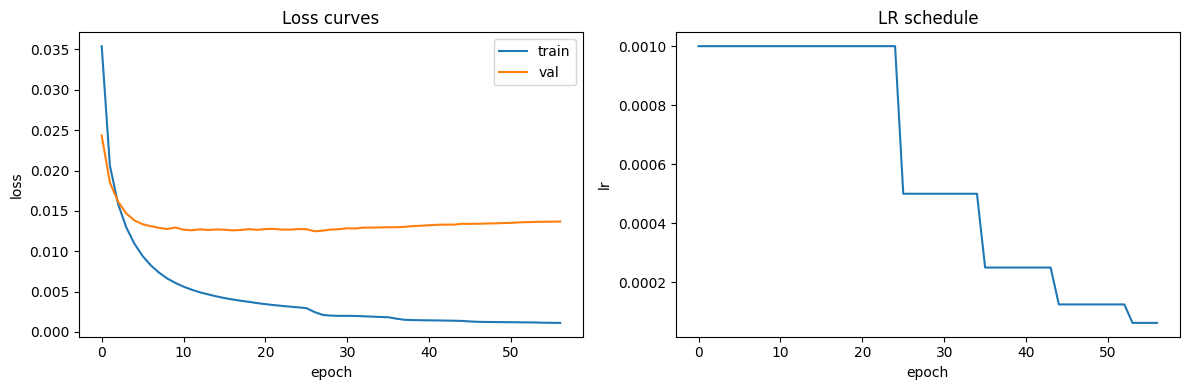

In [13]:
# Loss curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(train_history, label="train")
ax[0].plot(val_history, label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].set_title("Loss curves"); ax[0].legend()
ax[1].plot(lr_history); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("lr")
ax[1].set_title("LR schedule")
plt.tight_layout(); plt.show()

## 8. Главное: оценка best checkpoint на ВСЕХ 4 множествах

Это ключевая часть эксперимента. Сравниваем:
- **train-seen** (5200): что модель видела
- **train-fresh** (1000): не видела, но **то же распределение**, что train
- **val** (1000): прежний val
- **test** (800): прежний test

In [14]:
# Reload best ckpt
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint from epoch {best_ckpt['best_epoch']}")

print("\nEvaluating on all 4 sets...\n")

t0 = time.time()
m_train_seen  = evaluate_dataset(model, ds_train_seen,  device, stats["c_min"], stats["c_max"])
print(f"  train-seen done  ({len(m_train_seen):4d} samples)  [{time.time()-t0:.1f}s]")

t0 = time.time()
m_train_fresh = evaluate_dataset(model, ds_train_fresh, device, stats["c_min"], stats["c_max"])
print(f"  train-fresh done ({len(m_train_fresh):4d} samples)  [{time.time()-t0:.1f}s]")

t0 = time.time()
m_val   = evaluate_dataset(model, ds_val,   device, stats["c_min"], stats["c_max"])
print(f"  val done         ({len(m_val):4d} samples)  [{time.time()-t0:.1f}s]")

t0 = time.time()
m_test  = evaluate_dataset(model, ds_test,  device, stats["c_min"], stats["c_max"])
print(f"  test done        ({len(m_test):4d} samples)  [{time.time()-t0:.1f}s]")

s_train_seen  = summarize_metrics(m_train_seen)
s_train_fresh = summarize_metrics(m_train_fresh)
s_val         = summarize_metrics(m_val)
s_test        = summarize_metrics(m_test)

print("\n=== SUMMARY (RMSE in m/s, mean ± std) ===\n")
print(f"  {'set':<14}{'n':>6}    {'rmse_mean':>10}{'rmse_std':>10}{'psnr_mean':>10}")
print("  " + "-" * 50)
print(f"  {'train-seen':<14}{len(m_train_seen):>6}    {s_train_seen['rmse_mean']:>10.3f}{s_train_seen['rmse_std']:>10.3f}{s_train_seen['psnr_mean']:>10.3f}")
print(f"  {'train-fresh':<14}{len(m_train_fresh):>6}    {s_train_fresh['rmse_mean']:>10.3f}{s_train_fresh['rmse_std']:>10.3f}{s_train_fresh['psnr_mean']:>10.3f}")
print(f"  {'val':<14}{len(m_val):>6}    {s_val['rmse_mean']:>10.3f}{s_val['rmse_std']:>10.3f}{s_val['psnr_mean']:>10.3f}")
print(f"  {'test':<14}{len(m_test):>6}    {s_test['rmse_mean']:>10.3f}{s_test['rmse_std']:>10.3f}{s_test['psnr_mean']:>10.3f}")

Loaded best checkpoint from epoch 27

Evaluating on all 4 sets...

  train-seen done  (5200 samples)  [13.9s]
  train-fresh done (1000 samples)  [2.6s]
  val done         (1000 samples)  [2.6s]
  test done        ( 800 samples)  [2.1s]

=== SUMMARY (RMSE in m/s, mean ± std) ===

  set                n     rmse_mean  rmse_std psnr_mean
  --------------------------------------------------
  train-seen      5200         4.431     0.543    32.899
  train-fresh     1000        10.151     3.898    26.282
  val             1000        10.155     3.808    26.252
  test             800        16.817     4.869    21.647


## 9. Вердикт

Главное соотношение: **train-fresh RMSE vs train-seen RMSE vs test RMSE**.

In [15]:
rmse_seen  = s_train_seen["rmse_mean"]
rmse_fresh = s_train_fresh["rmse_mean"]
rmse_val   = s_val["rmse_mean"]
rmse_test  = s_test["rmse_mean"]

# Three diagnostic ratios
ratio_fresh_over_seen = rmse_fresh / max(rmse_seen, 1e-6)
ratio_test_over_seen  = rmse_test  / max(rmse_seen, 1e-6)
ratio_test_over_fresh = rmse_test  / max(rmse_fresh, 1e-6)

print("=== Diagnostic ratios ===\n")
print(f"  train-fresh / train-seen = {ratio_fresh_over_seen:.2f}")
print(f"  test        / train-seen = {ratio_test_over_seen:.2f}")
print(f"  test        / train-fresh = {ratio_test_over_fresh:.2f}\n")

print("=== Verdict ===\n")
if ratio_fresh_over_seen < 1.5 and ratio_test_over_fresh > 2.0:
    verdict = "DISTRIBUTION SHIFT (Hypothesis B)"
    explanation = (
        "  train-fresh ≈ train-seen → модель РЕАЛЬНО решает задачу на train-распределении.\n"
        "  test ≫ train-fresh        → test действительно из ДРУГОГО распределения.\n\n"
        "  Действие: capacity / архитектурные эксперименты НЕ помогут. Нужно либо\n"
        "  собрать данные из распределения, похожего на test, либо менять стратегию\n"
        "  generalization (domain adaptation, augmentation, multi-frequency)."
    )
elif ratio_fresh_over_seen > 2.0 and ratio_test_over_fresh < 1.5:
    verdict = "MEMORIZATION (Hypothesis A)"
    explanation = (
        "  train-fresh ≈ test         → модель НЕ генерализует даже внутри train-распределения.\n"
        "  train-seen ≪ train-fresh   → train-seen RMSE низкий ТОЛЬКО потому, что модель запомнила примеры.\n\n"
        "  Действие: capacity / регуляризация имеют смысл, потому что модель плохо\n"
        "  обобщает. Стоит попробовать: больше данных, увеличенный data augmentation,\n"
        "  более жёсткую регуляризацию, или меньшую модель."
    )
elif ratio_fresh_over_seen < 1.5 and ratio_test_over_fresh < 1.5:
    verdict = "NO PROBLEM"
    explanation = (
        "  Все три RMSE близки друг к другу. Это не overfit и не distribution shift.\n"
        "  Проверь, не сломан ли eval pipeline."
    )
else:
    verdict = "MIXED REGIME"
    explanation = (
        "  И memorization, и distribution shift присутствуют частично.\n"
        "  train-fresh падает между train-seen и test, но не сильно близко ни к одному.\n"
        "  В этом случае помогут оба направления — и больше данных/регуляризации,\n"
        "  и улучшение схожести train/test распределений."
    )

print(f"  {verdict}\n")
print(explanation)

=== Diagnostic ratios ===

  train-fresh / train-seen = 2.29
  test        / train-seen = 3.80
  test        / train-fresh = 1.66

=== Verdict ===

  MIXED REGIME

  И memorization, и distribution shift присутствуют частично.
  train-fresh падает между train-seen и test, но не сильно близко ни к одному.
  В этом случае помогут оба направления — и больше данных/регуляризации,
  и улучшение схожести train/test распределений.


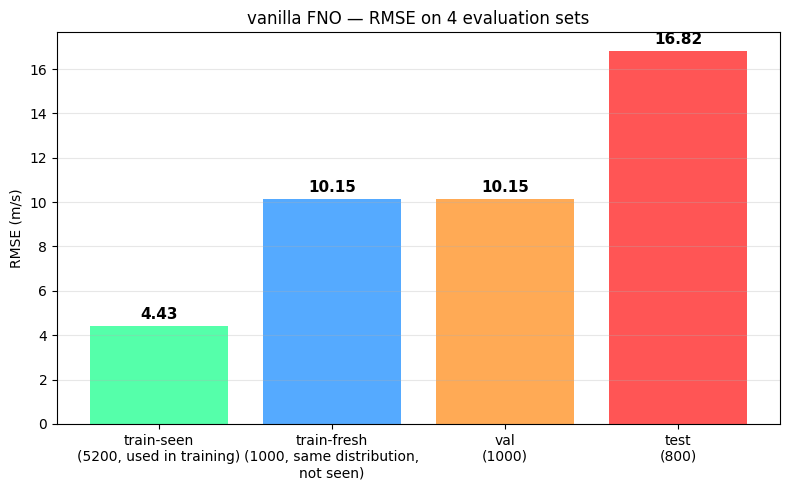

In [16]:
# Visual: bar chart
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["train-seen\n(5200, used in training)", "train-fresh\n(1000, same distribution,\nnot seen)", "val\n(1000)", "test\n(800)"]
values = [rmse_seen, rmse_fresh, rmse_val, rmse_test]
colors = ["#5fa", "#5af", "#fa5", "#f55"]

bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("RMSE (m/s)")
ax.set_title("vanilla FNO — RMSE on 4 evaluation sets")
ax.grid(axis="y", alpha=0.3)

for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.2f}",
            ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(RUN_DIR / "distshift_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## 10. Save artifacts

In [17]:
with open(RUN_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump({
        "verdict": verdict,
        "ratios": {
            "fresh_over_seen": ratio_fresh_over_seen,
            "test_over_seen": ratio_test_over_seen,
            "test_over_fresh": ratio_test_over_fresh,
        },
        "train_seen":  s_train_seen,
        "train_fresh": s_train_fresh,
        "val":         s_val,
        "test":        s_test,
        "config":      CFG,
        "best_epoch":  int(best_ckpt["best_epoch"]),
        "best_val":    float(best_ckpt["best_val"]),
    }, f, ensure_ascii=False, indent=2)

with open(RUN_DIR / "per_sample_metrics.json", "w", encoding="utf-8") as f:
    json.dump({
        "train_seen":  m_train_seen,
        "train_fresh": m_train_fresh,
        "val":         m_val,
        "test":        m_test,
    }, f, ensure_ascii=False, indent=2)

np.savez_compressed(
    RUN_DIR / "loss_history.npz",
    train_loss=np.array(train_history, dtype=np.float32),
    val_loss=np.array(val_history, dtype=np.float32),
    lr=np.array(lr_history, dtype=np.float32),
)
print(f"saved to {RUN_DIR}")

saved to /workspace/reference_points/distribution_shift_diagnostic


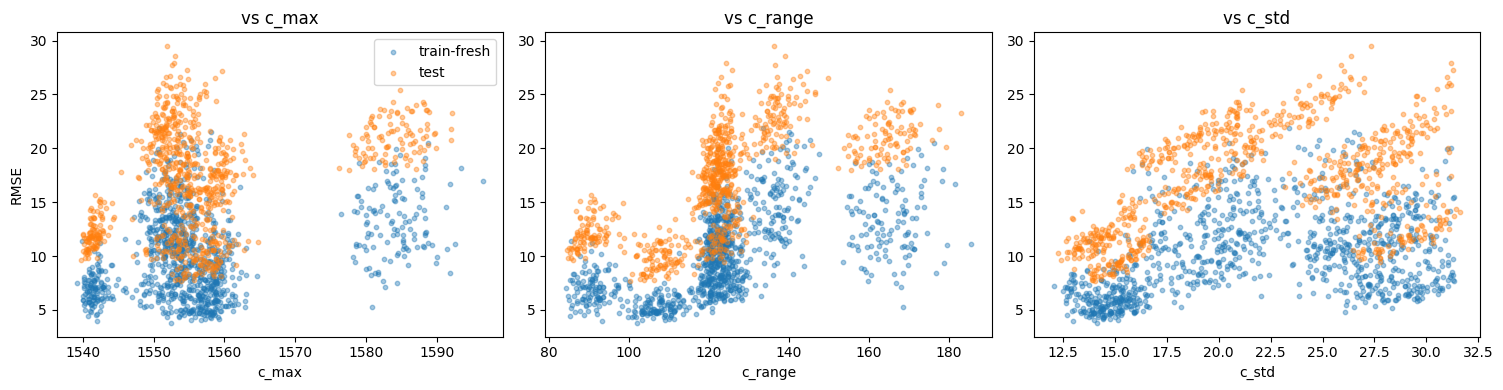

In [18]:
m_fresh = m_train_fresh  # из notebook 26
m_t = m_test

import numpy as np

def attrs(metrics_list):
    rmses, c_maxs, c_ranges, c_stds = [], [], [], []
    for m in metrics_list:
        c = np.load(m["path"])["c"].astype(np.float32)
        rmses.append(m["rmse"])
        c_maxs.append(float(c.max()))
        c_ranges.append(float(c.max() - c.min()))
        c_stds.append(float(c.std()))
    return np.array(rmses), np.array(c_maxs), np.array(c_ranges), np.array(c_stds)

r_fresh, max_fresh, range_fresh, std_fresh = attrs(m_fresh)
r_test, max_test, range_test, std_test = attrs(m_t)

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(max_fresh, r_fresh, alpha=0.4, s=10, label="train-fresh")
ax[0].scatter(max_test, r_test, alpha=0.4, s=10, label="test")
ax[0].set_xlabel("c_max"); ax[0].set_ylabel("RMSE"); ax[0].legend(); ax[0].set_title("vs c_max")

ax[1].scatter(range_fresh, r_fresh, alpha=0.4, s=10)
ax[1].scatter(range_test, r_test, alpha=0.4, s=10)
ax[1].set_xlabel("c_range"); ax[1].set_title("vs c_range")

ax[2].scatter(std_fresh, r_fresh, alpha=0.4, s=10)
ax[2].scatter(std_test, r_test, alpha=0.4, s=10)
ax[2].set_xlabel("c_std"); ax[2].set_title("vs c_std")
plt.tight_layout(); plt.show()
